In [75]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor 
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import joblib


In [76]:
df = pd.read_csv('../dataset/final_dataset.csv', parse_dates=['date'])
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

df = df.sort_values('date').reset_index(drop=True)
print(df.columns)
print(df.head())

Index(['date', 'inflation', 'rice_price', 'chili_price', 'meat_price',
       'egg_price', 'restaurant_inflation', 'rainfall', 'lag_inflation',
       'lag_1', 'lag_2', 'rolling_3', 'inflation_momentum',
       'rice_price_pct_change', 'chili_price_pct_change',
       'meat_price_pct_change', 'egg_price_pct_change', 'rainfall_anomaly',
       'inflation_rolling_3', 'inflation_rolling_6'],
      dtype='object')
        date  inflation  rice_price  chili_price  meat_price  egg_price  \
0 2020-02-01   0.784603     24750.0      32400.0     58150.0    11850.0   
1 2020-03-01  -0.343512     25550.0      33100.0     38300.0    11850.0   
2 2020-04-01  -0.122868     26100.0      31050.0     43100.0    11900.0   
3 2020-05-01   0.049437     27750.0      32950.0     45300.0    12350.0   
4 2020-06-01   0.558618     32050.0      38450.0     36000.0    11500.0   

   restaurant_inflation    rainfall  lag_inflation     lag_1     lag_2  \
0              0.334371  226.586744       0.784603  0.784603 

In [77]:
split_date = '2025-10-01'
train = df[df['date'] < split_date].copy()
test = df[df['date'] >= split_date].copy()

X_train = train.drop(columns=['date', 'inflation'])
y_train = train['inflation']
X_test = test.drop(columns=['date', 'inflation'])
y_test = test['inflation']

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

Train shape: (68, 18)
Test shape: (3, 18)


In [78]:
model = Ridge()
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

mae_train = mean_absolute_error(y_train, y_pred_train)
mse_train = mean_squared_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)
mse_test = mean_squared_error(y_test, y_pred_test)

print(f"Training MAE: {mae_train:.4f}")
print(f"Training MSE: {mse_train:.4f}")
print(f"Test MAE: {mae_test:.4f}")
print(f"Test MSE: {mse_test:.4f}")
print(f"Test R²: {r2_score(y_test, y_pred_test):.4f}")

Training MAE: 0.0720
Training MSE: 0.0185
Test MAE: 0.0430
Test MSE: 0.0019
Test R²: 0.9979


In [79]:
results = pd.DataFrame({
    'date': test['date'].dt.strftime('%Y-%m-%d'),
    'Actual': y_test.values,
    'Predicted': y_pred_test
})
print(results.head())

          date    Actual  Predicted
68  2025-10-01 -0.202848  -0.236915
69  2025-11-01 -0.086954  -0.127427
70  2025-12-01  1.890861   1.945264


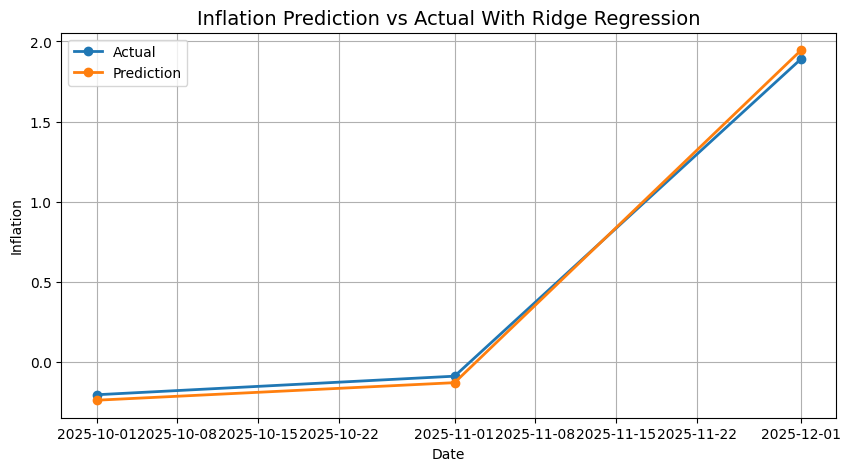

In [80]:
plt.figure(figsize=(10,5))

plt.plot(test["date"], y_test, marker="o", linewidth=2, label="Actual")
plt.plot(test["date"], y_pred_test, marker="o", linewidth=2, label="Prediction")

plt.title("Inflation Prediction vs Actual With Ridge Regression", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Inflation")
plt.grid(True)
plt.legend()

plt.show()

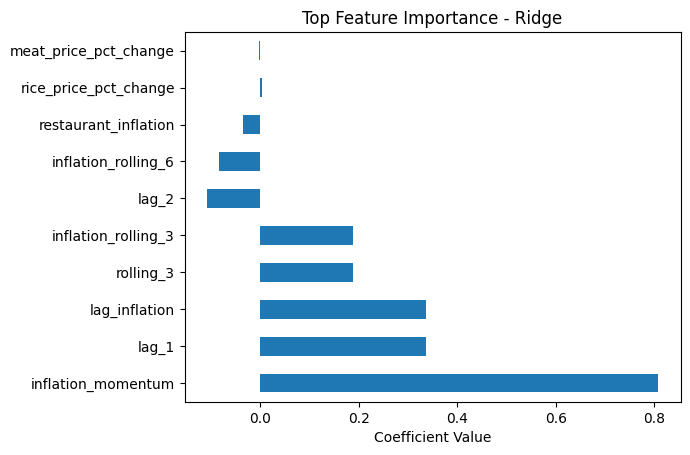

In [81]:
coef = pd.Series(model.coef_, index=X_train.columns)

coef = coef.sort_values(key=abs, ascending=False)
coef.head(10).plot(kind="barh")

plt.title("Top Feature Importance - Ridge")
plt.xlabel("Coefficient Value")
plt.show()

In [82]:
#Menggunakan XGBoost
X_train = train.drop(columns=['date', 'inflation'])
y_train = train['inflation']
X_test = test.drop(columns=['date', 'inflation'])
y_test = test['inflation']

xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=2, subsample=0.8, colsample_bytree=0.7, random_state=42)
xgb_model.fit(X_train, y_train)

y_pred_train = xgb_model.predict(X_train)
y_pred_test = xgb_model.predict(X_test)

In [83]:
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name} MAE : {mae:.4f}")
    print(f"{name} RMSE: {rmse:.4f}")
    print(f"{name} R²: {r2_score(y_true, y_pred):.4f}")

evaluate(y_train, y_pred_train, "Training")
evaluate(y_test, y_pred_test, "Test")

Training MAE : 0.1353
Training RMSE: 0.1834
Training R²: 0.9488
Test MAE : 0.2729
Test RMSE: 0.3968
Test R²: 0.8294


In [84]:
result = test[["date", "inflation"]].copy()
result["predicted"] = y_pred_test

print(result)

         date  inflation  predicted
68 2025-10-01  -0.202848  -0.216566
69 2025-11-01  -0.086954  -0.217326
70 2025-12-01   1.890861   1.216119


In [85]:
result = X_test.copy()
result["actual"] = y_test
result["prediction"] = y_pred_test

print(result)

    rice_price  chili_price  meat_price  egg_price  restaurant_inflation  \
68     31400.0      45000.0     41800.0    21000.0              0.064040   
69     31500.0      40250.0     41600.0    21000.0              0.073907   
70     32650.0      72400.0     52500.0    21100.0              0.246291   

      rainfall  lag_inflation     lag_1     lag_2  rolling_3  \
68   90.410757       0.246291  0.246291 -0.315828  -0.090795   
69  167.300274      -0.202848 -0.202848  0.246291  -0.014503   
70  233.294028      -0.086954 -0.086954 -0.202848   0.533687   

    inflation_momentum  rice_price_pct_change  chili_price_pct_change  \
68           -0.449139               3.119869               -8.443540   
69            0.115894               0.318471              -10.555556   
70            1.977815               3.650794               79.875776   

    meat_price_pct_change  egg_price_pct_change  rainfall_anomaly  \
68              -7.726269              -0.23753         -0.501608   
69     

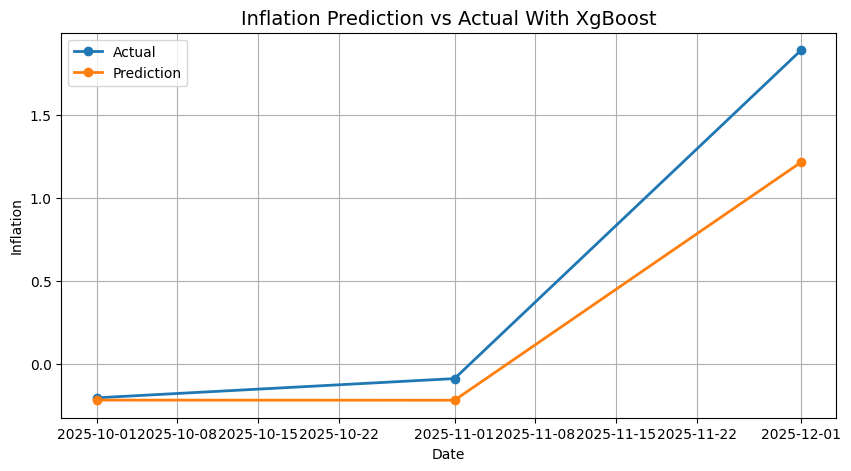

In [86]:
plt.figure(figsize=(10,5))

plt.plot(test["date"], y_test, marker="o", linewidth=2, label="Actual")
plt.plot(test["date"], y_pred_test, marker="o", linewidth=2, label="Prediction")

plt.title("Inflation Prediction vs Actual With XgBoost", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Inflation")
plt.grid(True)
plt.legend()

plt.show()

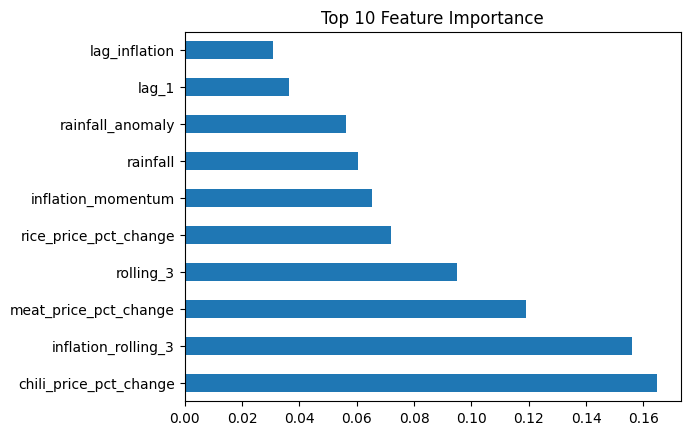

In [87]:
feature_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feature_importance.head(10).plot(kind='barh')
plt.title("Top 10 Feature Importance")
plt.show()

In [88]:
#save model yang menggunakan XgBoost
joblib.dump(xgb_model, 'xgb_model.pkl')


['xgb_model.pkl']